In [1]:
from pathlib import Path
import requests
import time
import xml.etree.ElementTree as ET
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from scipy.special import logsumexp
import matplotlib.pyplot as plt


In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

categories = [
    "cs.CL",
    "cs.CV",
    "math.PR",
    "physics.optics",
    "q-bio.NC",
    "econ.EM"
]

**Descarga y preprocesamiento de dataset**



In [3]:
BASE_URL = "http://export.arxiv.org/api/query"
for category in categories:

    category_dir = DATA_DIR / category.replace(".", "_")
    category_dir.mkdir(exist_ok=True)

    for start in range(0, 1000, 100):

        print(f"Descargando {category}: {start+100}/1000")

        params = {
            "search_query": f"cat:{category}",
            "start": start,
            "max_results": 100,
            "sortBy": "submittedDate",
            "sortOrder": "descending"
        }

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=60
        )

        response.raise_for_status()

        output_file = category_dir / f"batch_{start}.xml"

        with open(output_file, "w", encoding="utf-8") as f:
            f.write(response.text)

        # Respetar la API de arXiv
        time.sleep(3)

print("Descarga finalizada.")

Descargando cs.CL: 100/1000
Descargando cs.CL: 200/1000
Descargando cs.CL: 300/1000
Descargando cs.CL: 400/1000
Descargando cs.CL: 500/1000
Descargando cs.CL: 600/1000
Descargando cs.CL: 700/1000
Descargando cs.CL: 800/1000
Descargando cs.CL: 900/1000
Descargando cs.CL: 1000/1000
Descargando cs.CV: 100/1000
Descargando cs.CV: 200/1000
Descargando cs.CV: 300/1000
Descargando cs.CV: 400/1000
Descargando cs.CV: 500/1000
Descargando cs.CV: 600/1000
Descargando cs.CV: 700/1000
Descargando cs.CV: 800/1000
Descargando cs.CV: 900/1000
Descargando cs.CV: 1000/1000
Descargando math.PR: 100/1000
Descargando math.PR: 200/1000
Descargando math.PR: 300/1000
Descargando math.PR: 400/1000
Descargando math.PR: 500/1000
Descargando math.PR: 600/1000
Descargando math.PR: 700/1000
Descargando math.PR: 800/1000
Descargando math.PR: 900/1000
Descargando math.PR: 1000/1000
Descargando physics.optics: 100/1000
Descargando physics.optics: 200/1000
Descargando physics.optics: 300/1000
Descargando physics.optics

In [4]:


DATA_DIR = Path("data")

ns = {
    "atom": "http://www.w3.org/2005/Atom"
}

records = []

for category_dir in DATA_DIR.iterdir():

    if not category_dir.is_dir():
        continue

    category = category_dir.name.replace("_", ".")

    for xml_file in category_dir.glob("*.xml"):

        tree = ET.parse(xml_file)
        root = tree.getroot()

        for entry in root.findall("atom:entry", ns):

            title = entry.find("atom:title", ns)
            summary = entry.find("atom:summary", ns)

            records.append({
                "category": category,
                "title": title.text.strip(),
                "summary": summary.text.strip()
            })

df = pd.DataFrame(records)

print(df.shape)
df.head()

(6000, 3)


,category,title,summary
0,physics.optics,Bound states of solitons in fiber lasers,This article presents a systematic review of t...
1,physics.optics,Analysis of Electromagnetic Scattering from Se...,Semiconductor-based plasmonic nanostructures s...
2,physics.optics,Many-mode grating couplers by avoiding undesir...,To couple many independent modes from free spa...
3,physics.optics,Multimode grating couplers via foundry-complia...,We apply a systematic inverse design approach ...
4,physics.optics,Deep Strong light-matter Coupling in 3D Kane F...,Deep strong light-matter coupling represents a...


In [5]:
dataset = df.copy()

dataset["text"] = (
    dataset["title"].str.strip()
    + " "
    + dataset["summary"].str.strip()
)

dataset = dataset[["text", "category"]]

dataset = dataset.rename(
    columns={
        "category": "label"
    }
)

dataset

,text,label
0,Bound states of solitons in fiber lasers This ...,physics.optics
1,Analysis of Electromagnetic Scattering from Se...,physics.optics
2,Many-mode grating couplers by avoiding undesir...,physics.optics
3,Multimode grating couplers via foundry-complia...,physics.optics
4,Deep Strong light-matter Coupling in 3D Kane F...,physics.optics
...,...,...
5995,Semantic-Aware Guided Drone Exploration for La...,cs.CV
5996,SLIP-RS: Structured-Attribute Language-Image P...,cs.CV
5997,VisAnalog: A Diagnostic Suite for Visual Conce...,cs.CV
5998,STAMBRIDGE: Spectral-Temporal Amplitude-aware ...,cs.CV


In [6]:
labels = sorted(dataset["label"].unique())

label_to_id = {
    label: idx
    for idx, label in enumerate(labels)
}

X = dataset["text"].to_numpy()

y = np.array(
    [label_to_id[label] for label in dataset["label"]],
    dtype=np.int64
)

print(X.shape)
print(y.shape)

(6000,)
(6000,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=10072003,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(4800,)
(1200,)
(4800,)
(1200,)


Una vez definidos los conjuntos de entrenamiento y de testeo, se utiliza count vectorizer para obtener la ocurrencia de las palabras en cada uno de los textos y para deshacerse de palabras que puedan no ser representativas de los textos a la hora de entrenar el modelo.
- El parámetro _stop_words_ se utiliza para eliminar palabras de un idioma que no agreguen información relevante para este tipo de modelos, que asumen que todas las palabras del texto son independientes entre si. Estas palabras suelen ser artículos, preposiciones, etc.
- El parámetro _min_df_ se deshace de palabras con poca ocurrencia en los textos, si la entrada es un valor entre cero y uno lo toma con el porcentaje de los textos en los que debe aparecer la palabra para ser considerada, y si es un número mayor a uno, toma la ocurrencia absoluta de la palabra en los textos (cantidad de veces que aparece).
- El parámetro _max_df_ se deshace de palabras con demasiada ocurrencia, de la misma forma que con _min_df_, puede tomar números entre 0 y 1 o enteros, dependiendo si se quiere limitar a un porcentaje o a una cantidad absoluta de ocurrencias.

Cabe destacar, que debido a su naturaleza, se debe cumplir que $\textit{min_df} < \textit{max_df}$.

In [8]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=0.05,
    max_df=0.85
)

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

**Multinomial Naive Bayes**

Para el Bayes Naive primero se asume que independencia entre las muestras, lo que permite escribir:

$$p(y|x) \propto c_y \prod_{m=1}^V \left( \theta_m^{(y)}\right)^{N_m}$$

Donde $N_m$ es la cantidad de casos que se encuentran en la clase m y son estadisticos suficientes del modelo.

Para el caso multinomial se toma $c_k = \frac{#\{y_i = k\}}{n}$ y los $\theta s$ serán modelados de forma bayesiana.

El estimador puntual bayesiano utilizado será el siguiente:

$$\theta^{(k)}_m = \frac{Ñ_m^{(k)}+\alpha_m}{\sum^V_{\eta = 1}Ñ_{\eta}^{(k)}+ \alpha_{\eta}}$$

Donde $\tilde{N}_{m}^{(k)}$ se define como:

$$
\tilde{N}_{m}^{(k)}
=
\sum_{i=1}^{n}
N_{i,m}\,\mathbf{1}\{y_i = k\}
$$

Esto significa que se toma como si hubiera un unico texto por cada clase, concatenando todos los textos de dicha clase en uno solo.





In [9]:
class MultinomialNaiveBayes:

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):

        X = X.tocsr()

        self.classes_ = np.unique(y)

        n_classes = len(self.classes_)
        n_features = X.shape[1]

        self.class_log_prior_ = np.zeros(n_classes)
        self.feature_log_prob_ = np.zeros((n_classes, n_features))

        n_documents = len(y)

        for idx, c in enumerate(self.classes_):

            mask = (y == c)

            X_c = X[mask]

            # P(c)
            n_c = mask.sum()

            self.class_log_prior_[idx] = np.log(
                n_c / n_documents
            )

            # Conteos por palabra en la clase
            word_counts = np.asarray(
                X_c.sum(axis=0)
            ).ravel()

            # Total de palabras de la clase
            total_words = word_counts.sum()

            # Laplace smoothing
            prob = (
                word_counts + self.alpha
            ) / (
                total_words + self.alpha * n_features
            )

            self.feature_log_prob_[idx] = np.log(prob)

        return self

    def _joint_log_likelihood(self, X):

        X = X.tocsr()

        return (
            X @ self.feature_log_prob_.T
            + self.class_log_prior_
        )

    def predict_proba(self, X):

        log_probs = self._joint_log_likelihood(X)

        log_probs -= logsumexp(
            log_probs,
            axis=1,
            keepdims=True
        )

        return np.exp(log_probs)

    def predict(self, X):

        log_probs = self._joint_log_likelihood(X)

        indices = np.argmax(
            log_probs,
            axis=1
        )

        return self.classes_[indices]

Como para predecir se debe calcular el producto de las $\theta s$, se guarda el logaritmo de estas en vez del valor exacto, ya que de esta forma se convierte la productoria en una sumatoria, para evitar _underflow_

In [10]:
mnb = MultinomialNaiveBayes(alpha=1.0)

mnb.fit(X_train_bow, y_train)

y_pred = mnb.predict(X_test_bow)

y_prob = mnb.predict_proba(X_test_bow)

In [11]:
print(y_pred.shape)

print(y_prob.shape)

print(y_prob[0])

print(y_prob[0].sum())

(1200,)
(1200, 6)
[9.99093760e-01 9.06240377e-04 2.14547713e-28 5.78548416e-45
 1.36251624e-43 1.53288795e-13]
0.9999999999999828


In [12]:
accuracy = np.mean(y_pred == y_test)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8250


In [13]:
GRID_SIZE = 50

min_df_values = np.linspace(
    0.0,
    0.4,# 0,4 como limite, ya que es poco probable que una palabra este en la mitad de los docs(chqueado de forma empirica)
    GRID_SIZE,
    endpoint=True
)

max_df_values = np.linspace(
    0.0,
    1.0,
    GRID_SIZE,
    endpoint=True
)

results = np.full(
    (GRID_SIZE, GRID_SIZE),
    np.nan
)

In [14]:
for i, min_df in enumerate(min_df_values):

    for j, max_df in enumerate(max_df_values):

        if min_df >= max_df:
            continue

        try:

            vectorizer = CountVectorizer(
                stop_words="english",
                min_df=min_df,
                max_df=max_df
            )

            Xtr = vectorizer.fit_transform(X_train)
            Xte = vectorizer.transform(X_test)

            if Xtr.shape[1] == 0:
                continue

            model = MultinomialNaiveBayes()

            model.fit(Xtr, y_train)

            y_pred = model.predict(Xte)

            acc = np.mean(y_pred == y_test)

            results[i, j] = acc

        except ValueError:
            pass

In [15]:
validos = np.sum(~np.isnan(results))
total = results.size

print(validos)
print(total)

1876
2500


Se realiza un gráfico que muestra el accuracy en funcion de ambos parámetros, min_df y max_df. De esta forma se puede ver la dependencia del accuarcy con ambos. Se impone la limitación mencionada cuando se presentó la función _CountVectorizer_, además _min_df_ se limita a ser menor a 0,4 ya que valores más grandes impondrían que las palabras se repitan en mas del 50% de los textos, caso que es muy poco probable.

Se puede observar como el accuracy es máximo cuando _min_df_ es igual o cercano a cero, y decrece a medida que _max_df_ decrece o se acerca a _min_df_, el accuaracy alto puede ser indicio de overfitting, y el decreciemiento se puede aptribuir a la disminucion de la cantidad de palabras que se utilizan para entrenar el modelo.

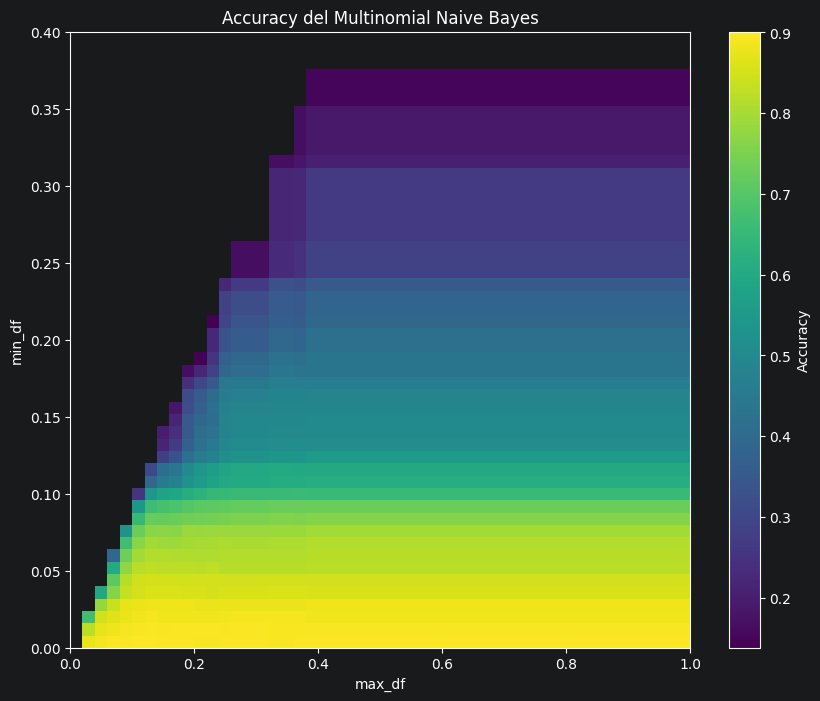

In [16]:
plt.figure(figsize=(10, 8))

im = plt.imshow(
    results,
    origin="lower",
    aspect="auto",
    extent=[
        max_df_values[0],
        max_df_values[-1],
        min_df_values[0],
        min_df_values[-1]
    ]
)

plt.xlabel("max_df")
plt.ylabel("min_df")

plt.title(
    "Accuracy del Multinomial Naive Bayes"
)

plt.colorbar(
    im,
    label="Accuracy"
)

plt.show()

Min_df no tiene sentido con valores mayores a 0,4. Sinificaria que una palabra deberia estar en la mitad de los documentos

In [17]:

N_POINTS = 100

max_df_values = np.linspace(
    0.001,
    1.0,
    N_POINTS
)

accuracies = []

for max_df in max_df_values:

    vectorizer = CountVectorizer(
        stop_words="english",
        min_df=0.0,
        max_df=max_df
    )

    try:

        Xtr = vectorizer.fit_transform(X_train)
        Xte = vectorizer.transform(X_test)

        if Xtr.shape[1] == 0:
            accuracies.append(np.nan)
            continue

        model = MultinomialNaiveBayes()

        model.fit(Xtr, y_train)

        y_pred = model.predict(Xte)

        accuracies.append(
            np.mean(y_pred == y_test)
        )

    except ValueError:

        accuracies.append(np.nan)

accuracies = np.array(accuracies)

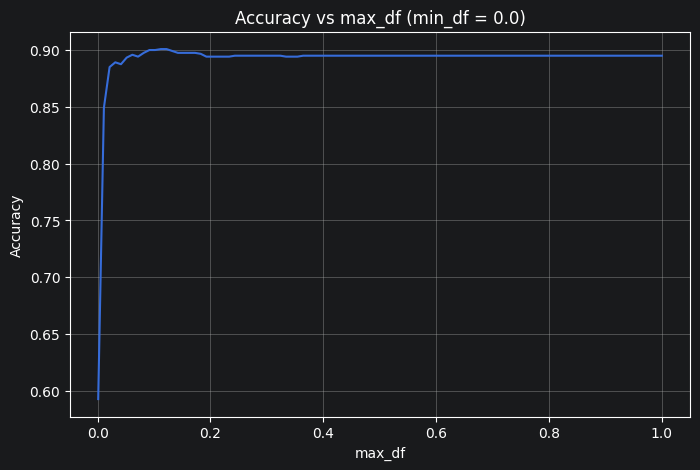

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    max_df_values,
    accuracies
)

plt.xlabel("max_df")
plt.ylabel("Accuracy")

plt.title(
    "Accuracy vs max_df (min_df = 0.0)"
)

plt.grid(True)

plt.show()

In [19]:
N_POINTS = 100

min_df_values = np.linspace(
    0.0,
    0.199,
    N_POINTS
)

accuracies = []

for min_df in min_df_values:

    vectorizer = CountVectorizer(
        stop_words="english",
        min_df=min_df,
        max_df=0.2
    )

    try:

        Xtr = vectorizer.fit_transform(X_train)
        Xte = vectorizer.transform(X_test)

        if Xtr.shape[1] == 0:
            accuracies.append(np.nan)
            continue

        model = MultinomialNaiveBayes()

        model.fit(Xtr, y_train)

        y_pred = model.predict(Xte)

        accuracies.append(
            np.mean(y_pred == y_test)
        )

    except ValueError:

        accuracies.append(np.nan)

accuracies = np.array(accuracies)

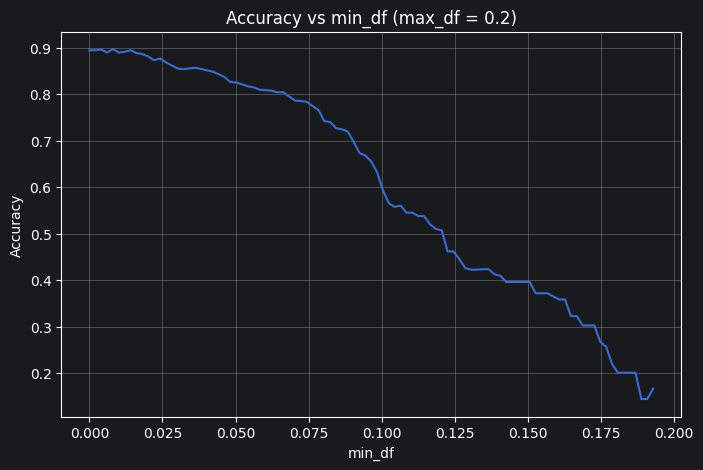

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    min_df_values,
    accuracies
)

plt.xlabel("min_df")
plt.ylabel("Accuracy")

plt.title(
    "Accuracy vs min_df (max_df = 0.2)"
)

plt.grid(True)

plt.show()

A medida que aumenta _min_df_ se necesita que para que una palabra sea valida se encuentre en más documentos, nuevamente achicando el numero de palabras que se usan para entrenar el modelo. 